## Part (a) — Design $\dot q = f(q)$ with a stable equilibrium at $q=1$

**Choice:**

$$\dot q = f(q) = k(1 - q), \qquad k > 0$$

**Equilibrium check:** $f(1) = k(1-1) = 0$ ✓ — so $q^*=1$ is indeed an
equilibrium.

**Stability check (linearization):**

$$\left.\frac{\partial f}{\partial q}\right|_{q=1} = -k < 0$$

A negative eigenvalue at the equilibrium confirms $q^*=1$ is **exponentially
stable**.

**Explicit solution (extra verification):** this linear ODE can be solved
in closed form:

$$q(t) = 1 - (1-q(0))\,e^{-kt} \;\xrightarrow[t\to\infty]{}\; 1$$

confirming convergence to $q=1$ from any initial condition, at a rate set
by the gain $k$. This function $f$ is reused in Part (b), applied to
$q=\dot\theta$, to drive the pendulum's angular velocity to a constant
value of 1 rad/s.

## Part (b) — Feedback cancellation control law

**System dynamics:**

$$ml^2\ddot\theta + mgl\sin\theta = ml\omega^2h\sin(\omega t)\cos\theta + u$$

**Goal:** design $u=\pi(\theta,\dot\theta,t)$ so that the closed-loop
dynamics become $\ddot\theta = f(\dot\theta)$, using $f$ from Part (a) with
$q=\dot\theta$:

$$\ddot\theta = f(\dot\theta) = k(1-\dot\theta)$$

**Derivation:** solve the system dynamics for $u$:

$$u = ml^2\ddot\theta + mgl\sin\theta - ml\omega^2h\sin(\omega t)\cos\theta$$

Substitute the desired closed-loop $\ddot\theta = k(1-\dot\theta)$:

$$\boxed{u = ml^2\,k(1-\dot\theta) + mgl\sin\theta - ml\omega^2h\sin(\omega t)\cos\theta}$$

**Interpretation:** this control law cancels both nonlinear disturbance
terms present in the original dynamics — gravity ($mgl\sin\theta$) and the
base-vibration forcing ($ml\omega^2h\sin(\omega t)\cos\theta$) — and replaces
them with exactly the torque needed to enforce the simple, already-proven-
stable target dynamics $\ddot\theta = k(1-\dot\theta)$ from Part (a). As
$t\to\infty$, this drives $\dot\theta \to 1$ rad/s, i.e., constant-velocity
spin.

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from pydrake.all import (
    AddMultibodyPlantSceneGraph,
    DiagramBuilder,
    LeafSystem,
    LogVectorOutput,
    MatrixGain,
    MeshcatVisualizer,
    Multiplexer,
    Parser,
    Simulator,
    StartMeshcat,
    plot_system_graphviz,
)
from underactuated import ConfigureParser, ManipulatorDynamics

In [38]:
meshcat = StartMeshcat()

INFO:drake:Meshcat listening for connections at http://localhost:7003


In [39]:
h = 1.0
omega = np.pi

In [40]:
builder = DiagramBuilder()

vibrating_pendulum, scene_graph = AddMultibodyPlantSceneGraph(
    builder,
    time_step=0.0,
)

parser = Parser(vibrating_pendulum)
ConfigureParser(parser)
parser.AddModelsFromUrl(
    "package://underactuated/models/vibrating_pendulum.urdf"
)
vibrating_pendulum.Finalize()

vibrating_pendulum.set_name("Vibrating Pendulum")
scene_graph.set_name("Scene Graph")

In [41]:
class InnerController(LeafSystem):
    def __init__(self, vibrating_pendulum):
        LeafSystem.__init__(self)
        self.DeclareVectorInputPort("u", 5)
        self.DeclareVectorOutputPort("y", 2, self.DoCalcVectorOutput)
        self.vibrating_pendulum = vibrating_pendulum

    def DoCalcVectorOutput(self, context, output):
        controller_input = self.get_input_port(0).Eval(context)
        q = controller_input[:2]
        q_dot = controller_input[2:4]

        M, Cv, tauG, B, tauExt = ManipulatorDynamics(self.vibrating_pendulum, q, q_dot)
        Minv = np.linalg.inv(M)
        tau = tauG - Cv

        t = context.get_time()
        a_base = -(omega**2) * h * np.sin(omega * t)

        torque = controller_input[-1]
        force = -tau[0]
        force += -(tau[1] + torque) * Minv[0, 1] / Minv[0, 0]
        force += a_base / Minv[0, 0]

        output.SetFromVector([force, torque])

In [42]:
def pendulum_torque(m, g, l, theta, theta_dot, t):
    k = 2.0
    desired_theta_ddot = k * (1 - theta_dot)
    torque = (
        m * l**2 * desired_theta_ddot
        + m * g * l * np.sin(theta)
        - m * l * omega**2 * h * np.sin(omega * t) * np.cos(theta)
    )
    return torque

In [43]:
class OuterController(LeafSystem):
    def __init__(self, vibrating_pendulum, pendulum_torque_func):
        LeafSystem.__init__(self)
        # 2 inputs: pendulum angle, pendulum angular velocity
        # 1 output: pendulum torque
        self.DeclareVectorInputPort("pendulum_state", 2)
        self.DeclareVectorOutputPort("torque", 1, self.DoCalcVectorOutput)
        self.vibrating_pendulum = vibrating_pendulum
        self.pendulum_torque_func = pendulum_torque_func

        # pendulum physical parameters -- adjust names if your URDF
        # uses different link/body names
        self.m = 1.0  # verify against URDF
        self.g = 9.81  # verify against URDF (may be 10)
        self.l = 1.0  # verify against URDF

    def DoCalcVectorOutput(self, context, output):
        pendulum_state = self.get_input_port(0).Eval(context)
        theta, theta_dot = pendulum_state
        t = context.get_time()
        torque = self.pendulum_torque_func(
            self.m, self.g, self.l, theta, theta_dot, t
        )
        output.SetFromVector([torque])

In [44]:
inner_controller = builder.AddNamedSystem(
    "Inner Controller", InnerController(vibrating_pendulum)
)
outer_controller = builder.AddNamedSystem(
    "Outer Controller", OuterController(vibrating_pendulum, pendulum_torque)
)

visualizer = MeshcatVisualizer.AddToBuilder(builder, scene_graph, meshcat)
visualizer.set_name("Visualizer")
meshcat.Set2dRenderMode(xmin=-2.5, xmax=2.5, ymin=-1.5, ymax=1.5)

logger = LogVectorOutput(vibrating_pendulum.get_state_output_port(), builder)
logger.set_name("Logger")

mux = builder.AddNamedSystem("Mux", Multiplexer([4, 1]))

selector = builder.AddNamedSystem(
    "Pendulum-State Selector",
    MatrixGain(
        np.array(
            [
                [0, 1, 0, 0],
                [0, 0, 0, 1],
            ]
        ),
    ),
)

builder.Connect(vibrating_pendulum.get_state_output_port(), mux.get_input_port(0))
builder.Connect(outer_controller.get_output_port(0), mux.get_input_port(1))
builder.Connect(mux.get_output_port(0), inner_controller.get_input_port(0))
builder.Connect(vibrating_pendulum.get_state_output_port(), selector.get_input_port(0))
builder.Connect(selector.get_output_port(0), outer_controller.get_input_port(0))
builder.Connect(
    inner_controller.get_output_port(0),
    vibrating_pendulum.get_actuation_input_port(),
)

diagram = builder.Build()
diagram.set_name("Block Diagram for the Control of the Vibrating Pendulum")

In [45]:
theta = 0.0
theta_dot = 0.0
sim_time = 10

visualizer.StartRecording()

simulator = Simulator(diagram)
simulator.set_publish_every_time_step(False)

context = simulator.get_mutable_context()
context.SetTime(0.0)
context.SetContinuousState(
    (
        0.0,
        theta,
        h * omega,
        theta_dot,
    )
)

simulator.Initialize()
simulator.AdvanceTo(sim_time)

/tmp/ipykernel_13641/1719518090.py:8: DrakeDeprecationWarning: (Deprecated.)

Deprecated:
    This is no longer controlled by the Simulator. It must be defined
    in the LeafSystem instead. See
    https://drake.mit.edu/troubleshooting.html#force-publishing for
    help. This will be removed from Drake on or after 2026-06-01.
  simulator.set_publish_every_time_step(False)


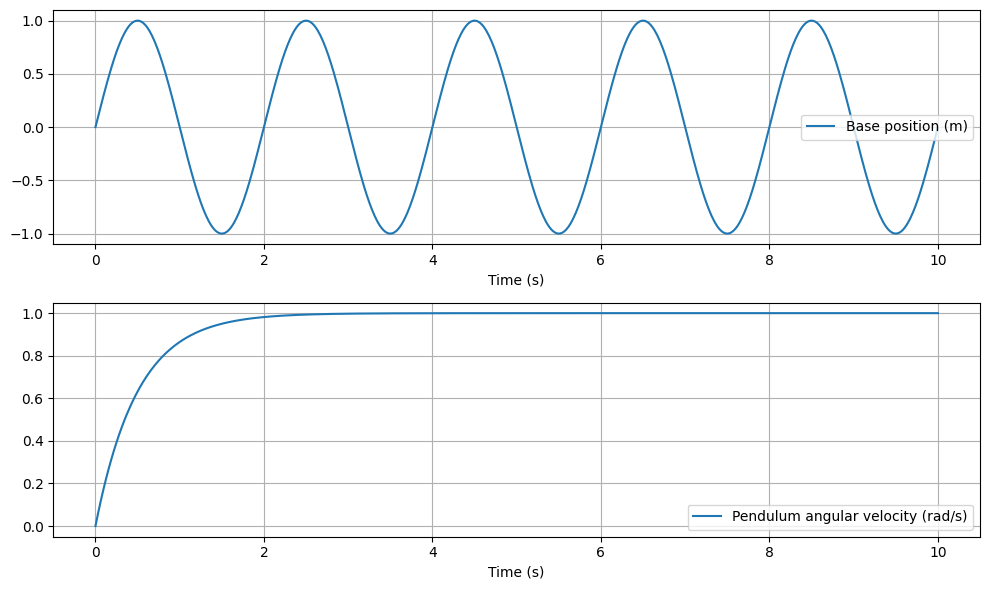

In [ ]:
log = logger.FindLog(context)

fig, ax = plt.subplots(2, 1, figsize=(10, 6))

ax[0].plot(log.sample_times(), log.data()[0, :], label="Base position (m)")
ax[0].set_xlabel("Time (s)")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(
    log.sample_times(),
    log.data()[-1, :],
    label="Pendulum angular velocity (rad/s)",
)
ax[1].set_xlabel("Time (s)")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()